In [1]:
# @title 1. Установка и импорты
!pip install tensorflow opencv-python matplotlib tqdm

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Add, Concatenate, Lambda
from tensorflow.keras.layers import Conv2D, Input, LeakyReLU
from tensorflow.keras.layers import UpSampling2D, ZeroPadding2D, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy, sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import cv2
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from PIL import Image
import zipfile

print("TensorFlow version:", tf.__version__)
print("GPU доступен:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# @title 2. Конфигурация для шахматных фигур
# Правильные имена классов (без пустого 0)
CLASS_NAMES = [
    'черный слон',      # 0
    'черный король',    # 1
    'черный конь',      # 2
    'черная пешка',     # 3
    'черный ферзь',     # 4
    'черная ладья',     # 5
    'белый слон',       # 6
    'белый король',     # 7
    'белый конь',       # 8
    'белая пешка',      # 9
    'белый ферзь',      # 10
    'белая ладья'       # 11
]
NUM_CLASSES = 12
SIZE = 416

# Якоря для YOLOv3
yolo_anchors = np.array([
    (10, 13), (16, 30), (33, 23),
    (30, 61), (62, 45), (59, 119),
    (116, 90), (156, 198), (373, 326)
], np.float32) / SIZE

yolo_anchor_masks = np.array([[6, 7, 8], [3, 4, 5], [0, 1, 2]])

In [3]:
# @title 3. Загрузка данных
!wget -O chess_yolo.zip https://storage.yandexcloud.net/academy.ai/CV/chess_yolo.zip

with zipfile.ZipFile('chess_yolo.zip', 'r') as zip_ref:
    zip_ref.extractall('chess_yolo')

BASE_PATH = "chess_yolo/chess_yolo"
TRAIN_IMAGES = f"{BASE_PATH}/train/images"
TRAIN_LABELS = f"{BASE_PATH}/train/labels"
VALID_IMAGES = f"{BASE_PATH}/valid/images"
VALID_LABELS = f"{BASE_PATH}/valid/labels"

print("Train images:", len(glob.glob(f"{TRAIN_IMAGES}/*.jpg")))
print("Valid images:", len(glob.glob(f"{VALID_IMAGES}/*.jpg")))

--2026-03-07 17:43:14--  https://storage.yandexcloud.net/academy.ai/CV/chess_yolo.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 39275734 (37M) [application/x-zip-compressed]
Saving to: ‘chess_yolo.zip’

chess_yolo.zip      100%[===================>]  37.46M  12.0MB/s    in 4.6s    

2026-03-07 17:43:20 (8.12 MB/s) - ‘chess_yolo.zip’ saved [39275734/39275734]

Train images: 606
Valid images: 58


In [4]:
# @title 4. Функции для построения модели YOLOv3
def DBL(x, filters, kernel, strides=1, batch_norm=True):
    if strides == 1:
        padding = 'same'
    else:
        x = ZeroPadding2D(((1, 0), (1, 0)))(x)
        padding = 'valid'

    x = Conv2D(filters=filters, kernel_size=kernel,
              strides=strides, padding=padding,
              use_bias=not batch_norm,
              kernel_regularizer=l2(0.0005))(x)

    if batch_norm:
        x = BatchNormalization(epsilon=0.001)(x)
        x = LeakyReLU(negative_slope=0.1)(x)
    return x

def ResUnit(x, filters):
    skip_connection = x
    x = DBL(x, filters // 2, 1)
    x = DBL(x, filters, 3)
    x = Add()([skip_connection, x])
    return x

def ResN(x, filters, blocks):
    x = DBL(x, filters, kernel=3, strides=2)
    for _ in range(blocks):
        x = ResUnit(x, filters)
    return x

def Darknet(name=None):
    x = inputs = Input([None, None, 3])
    x = DBL(x, 32, 3)
    x = ResN(x, 64, 1)
    x = ResN(x, 128, 2)
    x = route_1 = ResN(x, 256, 8)
    x = route_2 = ResN(x, 512, 8)
    route_3 = ResN(x, 1024, 4)
    return tf.keras.Model(inputs, (route_1, route_2, route_3), name=name)

def YoloHead(filters, name=None):
    def layer(x_in):
        if isinstance(x_in, tuple):
            inputs = [Input(x_in[0].shape[1:]), Input(x_in[1].shape[1:])]
            x, x_skip = inputs
            x = DBL(x, filters, 1)
            x = UpSampling2D(2)(x)
            x = Concatenate()([x, x_skip])
        else:
            x = inputs = Input(x_in.shape[1:])

        x = DBL(x, filters, 1)
        x = DBL(x, filters * 2, 3)
        x = DBL(x, filters, 1)
        x = DBL(x, filters * 2, 3)
        x = DBL(x, filters, 1)
        return Model(inputs, x, name=name)(x_in)
    return layer

def YoloHeadOutput(filters, anchors, classes, name=None):
    def layer(x_in):
        x = inputs = Input(x_in.shape[1:])
        x = DBL(x, filters * 2, 3)
        x = DBL(x, anchors * (classes + 5), 1, batch_norm=False)
        x = Lambda(lambda x: tf.reshape(x, (-1, tf.shape(x)[1], tf.shape(x)[2],
                                        anchors, classes + 5)))(x)
        return tf.keras.Model(inputs, x, name=name)(x_in)
    return layer

def YoloV3(size=None, channels=3, anchors=yolo_anchors,
           masks=yolo_anchor_masks, classes=NUM_CLASSES, training=True):
    x = inputs = Input([size, size, channels])

    route_1, route_2, route_3 = Darknet(name='yolo_darknet')(x)

    x = YoloHead(512, name='yolo_head_1')(route_3)
    output_0 = YoloHeadOutput(512, len(masks[0]), classes, name='yolo_output_1')(x)

    x = YoloHead(256, name='yolo_head_2')((x, route_2))
    output_1 = YoloHeadOutput(256, len(masks[1]), classes, name='yolo_output_2')(x)

    x = YoloHead(128, name='yolo_head_3')((x, route_1))
    output_2 = YoloHeadOutput(128, len(masks[2]), classes, name='yolo_output_3')(x)

    return Model(inputs, (output_0, output_1, output_2), name='yolov3')

In [5]:
# @title 5. Функции для преобразования bounding boxes
def yolo_boxes(pred, anchors, classes):
    grid_size = tf.shape(pred)[1]

    box_xy, box_wh, score, class_probs = tf.split(pred, (2, 2, 1, classes), axis=-1)

    box_xy = tf.sigmoid(box_xy)
    score = tf.sigmoid(score)
    class_probs = tf.sigmoid(class_probs)
    pred_box = tf.concat((box_xy, box_wh), axis=-1)

    grid = tf.meshgrid(tf.range(grid_size), tf.range(grid_size))
    grid = tf.expand_dims(tf.stack(grid, axis=-1), axis=2)

    b_xy = (box_xy + tf.cast(grid, tf.float32)) / tf.cast(grid_size, tf.float32)
    b_wh = tf.exp(box_wh) * anchors

    box_x1y1 = b_xy - b_wh / 2
    box_x2y2 = b_xy + b_wh / 2
    bbox = tf.concat([box_x1y1, box_x2y2], axis=-1)

    return bbox, score, class_probs, pred_box


In [6]:
# @title 6. Функция потерь YOLOv3
def yolo_loss(y_true, y_pred):
    """
    Полная функция потерь YOLOv3
    """
    # Объектность
    obj_true = y_true[..., 4:5]
    obj_pred = tf.sigmoid(y_pred[..., 4:5])
    obj_loss = tf.reduce_mean(tf.square(obj_true - obj_pred))

    # Маска для объектов
    obj_mask = obj_true > 0.5
    obj_mask_float = tf.cast(obj_mask, tf.float32)

    # Координаты
    xy_true = y_true[..., 0:2]
    xy_pred = tf.sigmoid(y_pred[..., 0:2])
    xy_loss = tf.reduce_sum(tf.square(xy_true - xy_pred), axis=-1, keepdims=True)
    xy_loss = obj_mask_float * xy_loss
    xy_loss = tf.reduce_mean(xy_loss)

    # Размеры
    wh_true = y_true[..., 2:4]
    wh_pred = y_pred[..., 2:4]
    wh_loss = tf.reduce_sum(tf.square(wh_true - wh_pred), axis=-1, keepdims=True)
    wh_loss = obj_mask_float * wh_loss
    wh_loss = tf.reduce_mean(wh_loss)

    # Классы
    class_true = tf.argmax(y_true[..., 5:], axis=-1)
    class_pred = tf.nn.softmax(y_pred[..., 5:])

    obj_mask_flat = tf.squeeze(obj_mask, axis=-1)
    class_loss = tf.keras.losses.sparse_categorical_crossentropy(class_true, class_pred)
    class_loss = tf.where(obj_mask_flat, class_loss, tf.zeros_like(class_loss))
    class_loss = tf.reduce_mean(class_loss)

    return xy_loss + wh_loss + obj_loss + class_loss


In [7]:
# @title 7. Загрузка данных в память
def parse_annotation(label_file):
    """Парсит файл разметки и возвращает боксы и классы"""
    boxes = []
    classes = []

    if not os.path.exists(label_file):
        return np.array(boxes), np.array(classes)

    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 9:
                class_id = int(parts[0])
                if 1 <= class_id <= 12:  # используем классы 1-12
                    coords = list(map(float, parts[1:]))
                    x_coords = coords[0::2]
                    y_coords = coords[1::2]
                    x1 = min(x_coords)
                    y1 = min(y_coords)
                    x2 = max(x_coords)
                    y2 = max(y_coords)
                    boxes.append([x1, y1, x2, y2])
                    classes.append(class_id - 1)  # сдвигаем на 0-11

    return np.array(boxes), np.array(classes)
def create_target_tensor(boxes, classes, grid_size, anchors, num_classes):
    """Создает target тензор для одного масштаба"""
    target = np.zeros((grid_size, grid_size, 3, 5 + num_classes), dtype=np.float32)

    if len(boxes) == 0:
        return target

    for box, cls in zip(boxes, classes):
        # Нормализованные координаты
        x_center = (box[0] + box[2]) / 2
        y_center = (box[1] + box[3]) / 2
        width = box[2] - box[0]
        height = box[3] - box[1]

        # Ячейка
        cell_x = int(x_center * grid_size)
        cell_y = int(y_center * grid_size)

        if cell_x >= grid_size or cell_y >= grid_size:
            continue

        # Выбираем лучший anchor по IoU
        best_iou = 0
        best_anchor = 0
        for a, (anchor_w, anchor_h) in enumerate(anchors):
            inter_w = min(anchor_w, width)
            inter_h = min(anchor_h, height)
            inter_area = inter_w * inter_h
            union_area = anchor_w * anchor_h + width * height - inter_area
            iou = inter_area / union_area if union_area > 0 else 0

            if iou > best_iou:
                best_iou = iou
                best_anchor = a

        # Заполняем target
        target[cell_y, cell_x, best_anchor, 0] = box[0]  # x1
        target[cell_y, cell_x, best_anchor, 1] = box[1]  # y1
        target[cell_y, cell_x, best_anchor, 2] = box[2]  # x2
        target[cell_y, cell_x, best_anchor, 3] = box[3]  # y2
        target[cell_y, cell_x, best_anchor, 4] = 1.0     # objectness
        target[cell_y, cell_x, best_anchor, 5 + cls] = 1.0  # class

    return target

def load_dataset(image_dir, label_dir):
    """Загружает датасет в память"""
    image_files = sorted(glob.glob(f"{image_dir}/*.jpg"))

    images = []
    all_boxes = []
    all_classes = []

    for img_file in tqdm(image_files):
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (SIZE, SIZE))
        img = img.astype(np.float32) / 255.0
        images.append(img)

        label_file = img_file.replace('/images/', '/labels/').replace('.jpg', '.txt')
        boxes, classes = parse_annotation(label_file)
        all_boxes.append(boxes)
        all_classes.append(classes)

    return np.array(images), all_boxes, all_classes

# Загружаем данные
print("Загрузка train данных...")
x_train, boxes_train, classes_train = load_dataset(TRAIN_IMAGES, TRAIN_LABELS)

print("Загрузка validation данных...")
x_val, boxes_val, classes_val = load_dataset(VALID_IMAGES, VALID_LABELS)

print(f"Train: {x_train.shape}")
print(f"Val: {x_val.shape}")

Загрузка train данных...


100%|██████████| 606/606 [00:01<00:00, 388.32it/s]


Загрузка validation данных...


100%|██████████| 58/58 [00:00<00:00, 400.52it/s]

Train: (606, 416, 416, 3)
Val: (58, 416, 416, 3)


In [8]:
# @title 8. Создание target тензоров
def create_targets_all_scales(boxes_list, classes_list, anchors, anchor_masks, grid_sizes=[13, 26, 52]):
    """Создает target тензоры для всех масштабов"""
    num_samples = len(boxes_list)
    targets = []

    for grid_size in grid_sizes:
        targets.append(np.zeros((num_samples, grid_size, grid_size, 3, 5 + NUM_CLASSES), dtype=np.float32))

    for i in range(num_samples):
        if len(boxes_list[i]) == 0:
            continue

        for j, grid_size in enumerate(grid_sizes):
            anchors_scale = anchors[anchor_masks[j]]
            target = create_target_tensor(
                boxes_list[i], classes_list[i],
                grid_size, anchors_scale, NUM_CLASSES
            )
            targets[j][i] = target

    return [tf.convert_to_tensor(t, dtype=tf.float32) for t in targets]

print("Создание target тензоров...")
y_train = create_targets_all_scales(boxes_train, classes_train, yolo_anchors, yolo_anchor_masks)
y_val = create_targets_all_scales(boxes_val, classes_val, yolo_anchors, yolo_anchor_masks)

print("Target shapes:")
for i, t in enumerate(y_train):
    print(f"  y_train[{i}].shape: {t.shape}")

Создание target тензоров...
Target shapes:
  y_train[0].shape: (606, 13, 13, 3, 17)
  y_train[1].shape: (606, 26, 26, 3, 17)
  y_train[2].shape: (606, 52, 52, 3, 17)


In [9]:
# @title 9. Создание tf.data.Dataset
batch_size = 4

train_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train, tuple(y_train))
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (x_val, tuple(y_val))
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Датасеты созданы")
for x, y in train_dataset.take(1):
    print(f"Images batch: {x.shape}")
    print(f"Targets: {[t.shape for t in y]}")

Датасеты созданы
Images batch: (4, 416, 416, 3)
Targets: [TensorShape([4, 13, 13, 3, 17]), TensorShape([4, 26, 26, 3, 17]), TensorShape([4, 52, 52, 3, 17])]


In [10]:
# @title 10. Создание модели
model = YoloV3(size=SIZE, classes=NUM_CLASSES, training=True)
print("Модель создана")

Модель создана


In [11]:
# @title 11. Компиляция модели
model.compile(optimizer=Adam(learning_rate=0.001), loss=yolo_loss)
print("Модель скомпилирована")

Модель скомпилирована


In [12]:
# @title 12. Callbacks
callbacks = [
    ModelCheckpoint('best_yolov3_chess.weights.h5', save_weights_only=True, save_best_only=True),
    ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    EarlyStopping(patience=5, verbose=1)
]
print("Callbacks готовы")

Callbacks готовы


In [13]:
# @title 13. Обучение
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 206s 742ms/step - loss: 10.1370 - yolo_output_1_loss: 0.3317 - yolo_output_2_loss: 0.0732 - yolo_output_3_loss: 0.0556 - val_loss: 4.2631 - val_yolo_output_1_loss: 0.0461 - val_yolo_output_2_loss: 0.0133 - val_yolo_output_3_loss: 0.0073 - learning_rate: 0.0010
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 59s 388ms/step - loss: 3.5476 - yolo_output_1_loss: 0.0702 - yolo_output_2_loss: 0.0166 - yolo_output_3_loss: 0.0038 - val_loss: 2.0420 - val_yolo_output_1_loss: 0.0487 - val_yolo_output_2_loss: 0.0127 - val_yolo_output_3_loss: 0.0047 - learning_rate: 0.0010
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 63s 415ms/step - loss: 1.7843 - yolo_output_1_loss: 0.0551 - yolo_output_2_loss: 0.0144 - yolo_output_3_loss: 0.0034 - val_loss: 1.2000 - val_yolo_output_1_loss: 0.0518 - val_yolo_output_2_loss: 0.0128 - val_yolo_output_3_loss: 0.0034 - learning_rate: 0.0010
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 64s 420ms/step - loss: 1.0937 - yolo_output_1_loss: 0.0552 - 

In [14]:
# @title 14. Сохранение модели
model.save_weights('chess_yolov3_final.weights.h5')
print("Модель сохранена")

Модель сохранена


In [28]:
# @title Финальная визуализация с фильтрацией
def visualize_filtered_detections(image_path, boxes, scores, classes, class_names,
                                   min_score=0.1, max_overlap=0.3):
    """
    Визуализация только уверенных детекций (> min_score)
    """
    # Загружаем изображение
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Фильтруем по уверенности
    high_conf_indices = [i for i, s in enumerate(scores) if s > min_score]

    if len(high_conf_indices) == 0:
        print(f" Нет детекций с уверенностью > {min_score}")
        # Покажем все для сравнения
        high_conf_indices = range(len(scores))

    filtered_boxes = [boxes[i] for i in high_conf_indices]
    filtered_scores = [scores[i] for i in high_conf_indices]
    filtered_classes = [classes[i] for i in high_conf_indices]

    # Применяем NMS еще раз с более строгим порогом
    final_boxes = []
    final_scores = []
    final_classes = []

    unique_classes = np.unique(filtered_classes)

    for cls in unique_classes:
        cls_indices = [i for i, c in enumerate(filtered_classes) if c == cls]
        cls_boxes = np.array([filtered_boxes[i] for i in cls_indices])
        cls_scores = np.array([filtered_scores[i] for i in cls_indices])

        # Более строгий NMS
        keep_boxes, keep_scores = non_max_suppression(cls_boxes, cls_scores, iou_threshold=max_overlap)

        final_boxes.extend(keep_boxes)
        final_scores.extend(keep_scores)
        final_classes.extend([cls] * len(keep_boxes))

    # Рисуем
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)

    colors = plt.cm.rainbow(np.linspace(0, 1, len(class_names)))

    for box, score, cls in zip(final_boxes, final_scores, final_classes):
        x1, y1, x2, y2 = box
        color = colors[int(cls)]

        # Более яркие цвета для уверенных детекций
        if score > 0.5:
            linewidth = 3
        elif score > 0.2:
            linewidth = 2
        else:
            linewidth = 1

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            fill=False, edgecolor=color, linewidth=linewidth
        )
        plt.gca().add_patch(rect)
        plt.text(x1, y1-5, f"{class_names[int(cls)]}\n{score:.2f}",
                color='white', fontsize=8,
                bbox=dict(facecolor=color, alpha=0.7))

    plt.title(f'Детекции с уверенностью > {min_score} (всего: {len(final_boxes)})')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Статистика
    print(f"\n Детекции с уверенностью > {min_score}:")
    confident = [(c, s) for c, s in zip(final_classes, final_scores) if s > min_score]
    for cls, score in confident:
        print(f"  {class_names[int(cls)]}: {score:.2f}")

    return final_boxes, final_scores, final_classes

# Тестируем с разными порогами
test_image = f"{VALID_IMAGES}/{os.listdir(VALID_IMAGES)[0]}"
img, boxes, scores, classes = predict_image(model, test_image, conf_threshold=0.01)

print("="*50)
print(" Детекции с порогом > 0.1:")
print("="*50)
visualize_filtered_detections(test_image, boxes, scores, classes, CLASS_NAMES, min_score=0.1)

print("\n" + "="*50)
print(" Детекции с порогом > 0.2:")
print("="*50)
visualize_filtered_detections(test_image, boxes, scores, classes, CLASS_NAMES, min_score=0.2)

print("\n" + "="*50)
print(" Детекции с порогом > 0.5:")
print("="*50)
visualize_filtered_detections(test_image, boxes, scores, classes, CLASS_NAMES, min_score=0.5)

 Детекции с порогом > 0.1:

 Детекции с уверенностью > 0.1:
  черная пешка: 0.74
  черная пешка: 0.66
  черная пешка: 0.57
  черная ладья: 0.29
  черная ладья: 0.18

 Детекции с порогом > 0.2:

 Детекции с уверенностью > 0.2:
  черная пешка: 0.74
  черная пешка: 0.66
  черная пешка: 0.57
  черная ладья: 0.29

 Детекции с порогом > 0.5:

 Детекции с уверенностью > 0.5:
  черная пешка: 0.74
  черная пешка: 0.66
  черная пешка: 0.57


([array([176,  79, 301, 204]),
  array([176, 207, 300, 332]),
  array([ 80, 111, 205, 236])],
 [np.float32(0.7430225), np.float32(0.65587), np.float32(0.5714662)],
 [np.int64(3), np.int64(3), np.int64(3)])

 Тестируем: IMG_0293_JPG.rf.e208f5cdf5e993c552be7f96e86c4890.jpg


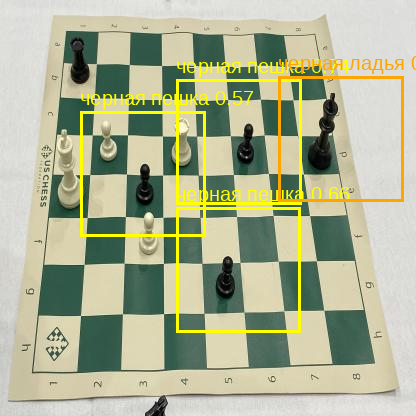


 Изображение сохранено как 'chess_detections_final.jpg'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Найдено объектов с уверенностью > 0.2: 4
1. черная пешка: увер=0.74
2. черная пешка: увер=0.66
3. черная пешка: увер=0.57
4. черная ладья: увер=0.29


In [32]:
# @title Финальная визуализация через PIL (100% работает)
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import cv2
from IPython.display import display

# Загружаем тестовое изображение
test_image = f"{VALID_IMAGES}/{os.listdir(VALID_IMAGES)[0]}"
print(f" Тестируем: {os.path.basename(test_image)}")

# Получаем предсказания
img, boxes, scores, classes = predict_image(model, test_image, conf_threshold=0.05)

# Отбираем уверенные детекции (>0.2)
confident_indices = [i for i, s in enumerate(scores) if s > 0.2]
confident_boxes = [boxes[i] for i in confident_indices]
confident_scores = [scores[i] for i in confident_indices]
confident_classes = [classes[i] for i in confident_indices]

# Открываем изображение через PIL
pil_image = Image.open(test_image)
draw = ImageDraw.Draw(pil_image)

# Пробуем загрузить шрифт (если не получится - используем дефолтный)
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf", 20)
except:
    font = ImageFont.load_default()

# Цвета для классов
colors = [
    'red', 'green', 'blue', 'yellow', 'purple', 'orange',
    'pink', 'cyan', 'brown', 'gray', 'olive', 'teal'
]

# Рисуем рамки
for box, score, cls in zip(confident_boxes, confident_scores, confident_classes):
    x1, y1, x2, y2 = box
    color = colors[int(cls) % len(colors)]

    # Рисуем прямоугольник
    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

    # Добавляем текст
    text = f"{CLASS_NAMES[int(cls)]} {score:.2f}"
    draw.text((x1, y1-25), text, fill=color, font=font)

# Показываем изображение
display(pil_image)

# Сохраняем
pil_image.save('chess_detections_final.jpg')
print("\n Изображение сохранено как 'chess_detections_final.jpg'")

# Скачиваем (опционально)
from google.colab import files
files.download('chess_detections_final.jpg')

# Выводим информацию в консоль
print(f"\n Найдено объектов с уверенностью > 0.2: {len(confident_boxes)}")
for i, (box, score, cls) in enumerate(zip(confident_boxes, confident_scores, confident_classes)):
    print(f"{i+1}. {CLASS_NAMES[int(cls)]}: увер={score:.2f}")